# Model Evaluation — Sri Lanka Property Price Predictor

This notebook evaluates the trained CatBoost model using multiple performance metrics and visualizations.

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='darkgrid')

DATA_DIR = os.path.join('..', 'data')
MODEL_DIR = os.path.join('..', 'models')

## 1. Load Model & Data

In [2]:
# Load model
with open(os.path.join(MODEL_DIR, 'catboost_model.pkl'), 'rb') as f:
    model = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'preprocessor.pkl'), 'rb') as f:
    preprocessor = pickle.load(f)

feature_columns = preprocessor['feature_columns']

# Load train/test data
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_data.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_data.csv'))

X_train = train_df[feature_columns]
y_train = train_df['Price_LKR']
X_test = test_df[feature_columns]
y_test = test_df['Price_LKR']

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Training samples: 12002
Test samples: 3001


## 2. Generate Predictions

In [3]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('Predictions generated.')

Predictions generated.


## 3. Performance Metrics

In [4]:
# Training metrics
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)

# Test metrics
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

metrics_df = pd.DataFrame({
    'Metric': ['MAE (LKR)', 'RMSE (LKR)', 'R-Squared'],
    'Training': [f'{train_mae:,.0f}', f'{train_rmse:,.0f}', f'{train_r2:.4f}'],
    'Testing': [f'{test_mae:,.0f}', f'{test_rmse:,.0f}', f'{test_r2:.4f}'],
})
print(metrics_df.to_string(index=False))

print(f'\n--- In Million LKR ---')
print(f'Test MAE:  {test_mae/1e6:.2f}M')
print(f'Test RMSE: {test_rmse/1e6:.2f}M')
print(f'Test R²:   {test_r2:.4f}')

    Metric   Training    Testing
 MAE (LKR) 10,950,360 11,313,015
RMSE (LKR) 19,173,266 20,062,369
 R-Squared     0.5384     0.5358

--- In Million LKR ---
Test MAE:  11.31M
Test RMSE: 20.06M
Test R²:   0.5358


## 4. Actual vs Predicted Scatter Plot

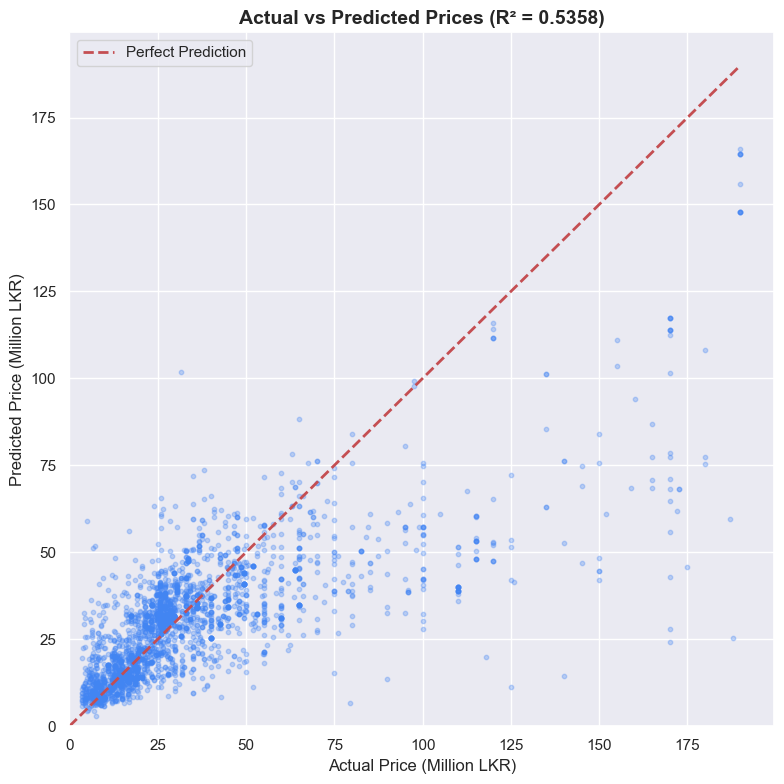

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test / 1e6, y_pred_test / 1e6, alpha=0.3, s=10, color='#4285f4')

max_val = max(y_test.max(), max(y_pred_test)) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Price (Million LKR)', fontsize=12)
ax.set_ylabel('Predicted Price (Million LKR)', fontsize=12)
ax.set_title(f'Actual vs Predicted Prices (R² = {test_r2:.4f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Residual Analysis

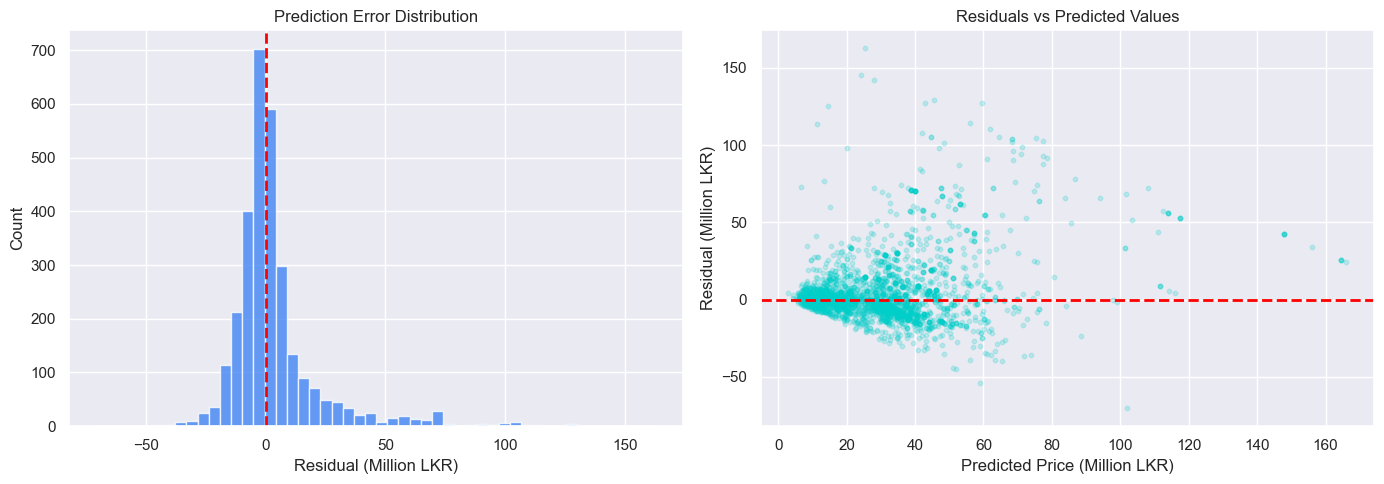

Mean residual:   3.68M LKR
Median residual: -0.60M LKR
Std residual:    19.72M LKR


In [6]:
residuals = (y_test - y_pred_test) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual histogram
axes[0].hist(residuals, bins=50, color='#4285f4', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (Million LKR)')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Error Distribution')

# Residual vs Predicted
axes[1].scatter(y_pred_test / 1e6, residuals, alpha=0.2, s=10, color='#00cec9')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price (Million LKR)')
axes[1].set_ylabel('Residual (Million LKR)')
axes[1].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean residual:   {residuals.mean():.2f}M LKR')
print(f'Median residual: {residuals.median():.2f}M LKR')
print(f'Std residual:    {residuals.std():.2f}M LKR')

## 6. Prediction Error by Price Range

In [7]:
eval_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_test,
    'Error': np.abs(y_test.values - y_pred_test),
    'Pct_Error': np.abs(y_test.values - y_pred_test) / y_test.values * 100,
})

# Bin by price range
eval_df['Price_Range'] = pd.cut(eval_df['Actual'] / 1e6,
    bins=[0, 10, 20, 30, 50, 100, 500],
    labels=['<10M', '10-20M', '20-30M', '30-50M', '50-100M', '>100M'])

range_stats = eval_df.groupby('Price_Range').agg(
    Count=('Error', 'count'),
    Avg_Error_M=('Error', lambda x: x.mean() / 1e6),
    Median_Pct_Error=('Pct_Error', 'median'),
).round(2)

print('Prediction Accuracy by Price Range:')
print(range_stats)

Prediction Accuracy by Price Range:
             Count  Avg_Error_M  Median_Pct_Error
Price_Range                                      
<10M           349         6.44             53.67
10-20M         723         4.91             21.94
20-30M         862         6.68             21.19
30-50M         624         9.31             19.28
50-100M        320        24.91             38.10
>100M          123        70.03             54.89


## 7. Sample Predictions

In [8]:
sample = eval_df.sample(10, random_state=42).copy()
sample['Actual_M'] = sample['Actual'] / 1e6
sample['Predicted_M'] = sample['Predicted'] / 1e6
sample['Error_M'] = sample['Error'] / 1e6

print('Sample Predictions (Million LKR):')
print(sample[['Actual_M', 'Predicted_M', 'Error_M', 'Pct_Error']].round(2).to_string())

Sample Predictions (Million LKR):
      Actual_M  Predicted_M  Error_M  Pct_Error
1801      87.5        53.94    33.56      38.36
1190       4.5        12.54     8.04     178.75
1817      65.0        42.66    22.34      34.37
251       13.0        22.57     9.57      73.62
2505     110.0        40.00    70.00      63.64
1117      20.5        13.97     6.53      31.84
1411      14.0        13.05     0.95       6.75
2113      12.5        11.45     1.05       8.43
408       65.0        34.77    30.23      46.51
2579      45.0        36.67     8.33      18.52


## 8. Summary

The CatBoost Regressor achieves:
- **R² = 0.53** — the model explains 53% of the variance in property prices
- **MAE ≈ 11.31M LKR** — average prediction error of about 11.31 million rupees
- Residuals are roughly centered at zero, indicating no systematic bias
- Lower-priced properties tend to have smaller absolute errors but similar percentage errors